# Representational Geometry as a Fidelity Metric for Connectome-Constrained Neural Emulations

**Experiment 2: ON + OFF Edges | Michael Zhou | Georgia Tech ECE**

This notebook extends Experiment 1 to test whether the representational geometry finding generalizes across stimulus polarity — using both ON and OFF moving edges as stimuli (24 conditions: 12 directions × 2 polarities). A fidelity signal that holds across polarities would strengthen the claim that representational geometry reflects a general property of connectome structure, not a feature of the ON pathway alone.

**Key question:** Does the direction-sensitive representational geometry observed for ON edges also emerge for OFF edges, and does the combined ON+OFF geometry remain specific to connectome-constrained networks?

**References**
- Lappalainen et al. 2024. Connectome-constrained networks predict neural activity across the fly visual system. *Nature* 634, 1132–1140. https://www.nature.com/articles/s41586-024-07939-3
- Shiu et al. 2024. A Drosophila computational brain model reveals sensorimotor processing. *Nature* 634, 210–219. https://www.nature.com/articles/s41586-024-07763-9
- Kriegeskorte et al. 2008. Representational similarity analysis. *Frontiers in Systems
  Neuroscience* 2:4. https://www.frontiersin.org/journals/systems-neuroscience/articles/10.3389/neuro.06.004.2008/full
- Kriegeskorte & Wei 2021. Neural tuning and representational geometry. *Nature Reviews
  Neuroscience* 22, 703–718. https://www.nature.com/articles/s41583-021-00502-3
- Nili et al. 2014. A toolbox for representational similarity analysis. *PLOS Computational Biology* 10(4): e1003553. https://doi.org/10.1371/journal.pcbi.1003553
- Brunton et al. 2026. The digital sphinx: Can a worm brain control a fly body? *bioRxiv*.
  https://www.biorxiv.org/content/10.64898/2026.03.20.713233v1

## Setup

Install Flyvis and download pretrained models. Select **Runtime → Change runtime type → GPU**
before running. Tested on T4 GPU (14.56 GiB).

In [1]:
# Install packages
!git clone https://github.com/TuragaLab/flyvis.git
%cd /content/flyvis
!pip install -e .[examples]
!flyvis download-pretrained

Cloning into 'flyvis'...
remote: Enumerating objects: 5230, done.
remote: Counting objects: 100% (247/247), done.
remote: Compressing objects: 100% (123/123), done.
remote: Total 5230 (delta 181), reused 155 (delta 122), pack-reused 4983 (from 3)
Receiving objects: 100% (5230/5230), 188.39 MiB | 27.03 MiB/s, done.
Resolving deltas: 100% (2675/2675), done.
/content/flyvis
Obtaining file:///content/flyvis
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 112.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 9.5 MB/s 

## Experiment
**Stimuli:** 24 moving edge conditions — 12 directions at 30° increments (0° through 330°) × 2 polarities (ON and OFF edges)

**Networks:**
- *Connectome-constrained (CC):* All 50 models in the pretrained Flyvis ensemble (indices `000–049` within `flow/0000`, pre-sorted by task error in directory naming), trained to perform optic flow estimation on naturalistic video with connectome-fixed architecture (734 free parameters)
- *Random baseline:* Same 50 model architectures with only the 604 unitary synapse scaling factors (`edges_syn_strength`) shuffled while preserving E/I sign structure, trained time constants, and resting potentials — per Lappalainen et al. (2024) Methods, time constants are clamped during training to prevent instability; preserving them produces a dynamically stable Shiu-style control

**Population vectors:** Peak central-cell voltage per cell type (65-dim) in response to each stimulus condition

**Reproducibility:** seed=42 (`numpy`, `torch`, `torch.cuda`); `torch.use_deterministic_algorithms(True)`

**Metrics:**
- Cosine distance RDM — scale-invariant, captures pattern geometry across all 24 conditions
- Euclidean distance RDM — captures magnitude differences
- Spearman RDM correlation — measures similarity between CC and random geometry
- Kendall's τ_A RDM correlation — preferred for RDM data with ties (Nili et al. 2014); reported alongside Spearman for all CC vs random comparisons
- Within-ensemble consistency — measures stability of CC representational geometry across trained solutions
- Polarity generalization — whether direction-sensitive geometry observed for ON edges in Experiment 1 extends to OFF edges and the combined ON+OFF space

In [6]:
"""
Experiment 2: Representational Geometry as a Fidelity Metric
for Connectome-Constrained Neural Emulations — ON + OFF Edges

This script extends Experiment 1 (ON edges only) to test whether connectome-constrained
networks (Lappalainen et al. 2024) produce geometrically distinct population codes
compared to randomly initialized networks when stimulated with both ON and OFF moving
edges. A meaningful fidelity signal across both polarities would strengthen the claim
that representational geometry is a general property of the connectome constraint,
not specific to the ON pathway.

Experiment:
- Stimuli: 24 moving edge conditions (12 directions × 2 polarities: ON and OFF)
- Networks: pretrained connectome-constrained ensemble (all 50) vs random baseline
- Population vectors: peak central-cell response per cell type (65-dim)
- Metrics: Euclidean distance, cosine distance, RSA (RDM correlation)

Run on Google Colab with GPU runtime after installing flyvis:
    !git clone https://github.com/TuragaLab/flyvis.git
    %cd /content/flyvis
    !pip install -e .[examples]
    !flyvis download-pretrained
"""

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine, euclidean
from scipy.stats import spearmanr, kendalltau

# ── 1. IMPORTS ────────────────────────────────────────────────────────────────

import flyvis
from flyvis import results_dir, EnsembleView
from flyvis.network import NetworkView
from flyvis.datasets.moving_bar import MovingEdge
from flyvis.utils.activity_utils import LayerActivity

# ── REPRODUCIBILITY ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.use_deterministic_algorithms(True)

# ── 2. STIMULUS DATASET ───────────────────────────────────────────────────────

ANGLES = [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330]  # 12 directions (30° increments)
INTENSITIES = [0, 1]                                                # ON (1) and OFF (0) edges

dataset = MovingEdge(
    offsets=[-10, 11],
    intensities=INTENSITIES,         # include both ON and OFF
    speeds=[19],
    height=80,
    post_pad_mode="continue",
    t_pre=1.0,
    t_post=1.0,
    dt=1 / 200,
    angles=ANGLES,
)

print(f"Dataset: {len(dataset)} samples")
print(dataset.arg_df)


# ── 3. HELPER: EXTRACT POPULATION VECTOR ─────────────────────────────────────

def get_population_vector(network_view, stimulus, dt, use_fade_in=True):
    """
    Simulate network response to a single stimulus and return
    peak central-cell voltage per cell type as a population vector.

    Args:
        network_view: flyvis NetworkView instance
        stimulus: tensor of shape (n_frames, 1, 721)
        dt: temporal resolution
        use_fade_in: whether to use fade_in_state initialization

    Returns:
        pop_vec: numpy array of shape (n_cell_types,)
        cell_types: list of cell type names
    """
    network = network_view.init_network()

    # Ensure shape is (n_frames, 1, 721) — MovingEdge returns (n_frames, 721)
    if stimulus.dim() == 2:
        stimulus = stimulus.unsqueeze(1)  # (n_frames, 721) -> (n_frames, 1, 721)

    if use_fade_in:
        initial_state = network.fade_in_state(1.0, dt, stimulus[[0]])
    else:
        initial_state = None

    with torch.no_grad():
        responses = network.simulate(
            stimulus[None], dt, initial_state=initial_state
        ).cpu()

    layer_act = LayerActivity(responses, network.connectome, keepref=True)

    # Use connectome to enumerate cell types — more reliable than central.keys()
    cell_types = [
        ct.decode() if isinstance(ct, bytes) else ct
        for ct in network.connectome.unique_cell_types[:]
    ]
    pop_vec = np.array([
        layer_act.central[ct].squeeze().numpy().max()
        for ct in cell_types
    ])

    # Free GPU memory after each model to avoid OOM on T4 (14.56 GiB)
    del network, responses, layer_act
    torch.cuda.empty_cache()

    return pop_vec, cell_types


# ── 4. HELPER: BUILD RDM ──────────────────────────────────────────────────────

def build_rdm(pop_matrix, metric="cosine"):
    """
    Build a representational dissimilarity matrix from a population matrix.

    Args:
        pop_matrix: numpy array of shape (n_stimuli, n_cells)
        metric: "cosine" or "euclidean"

    Returns:
        rdm: numpy array of shape (n_stimuli, n_stimuli)
    """
    # Replace any inf/nan with large finite value before computing distances.
    # Random baseline networks with unstable dynamics may produce exploding
    # activations; clamping preserves the comparison (an exploding network is
    # maximally different from a well-behaved biological one) while avoiding
    # downstream crashes.
    pop_matrix = np.nan_to_num(pop_matrix, nan=0.0, posinf=1e3, neginf=-1e3)

    n = pop_matrix.shape[0]
    rdm = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                if metric == "cosine":
                    rdm[i, j] = cosine(pop_matrix[i], pop_matrix[j])
                else:
                    rdm[i, j] = euclidean(pop_matrix[i], pop_matrix[j])
    return rdm


# ── 5. HELPER: COMPARE RDMs ──────────────────────────────────────────────────

def rdm_similarity(rdm1, rdm2):
    """
    Compute Spearman rank correlation and Kendall's tau_A between upper
    triangles of two RDMs. Kendall's tau_A is preferred for RDM data with
    ties (Nili et al. 2014); Spearman retained for comparison.
    """
    n = rdm1.shape[0]
    idx = np.triu_indices(n, k=1)
    r_s, p_s = spearmanr(rdm1[idx], rdm2[idx])
    r_k, p_k = kendalltau(rdm1[idx], rdm2[idx])
    return r_s, p_s, r_k, p_k


# ── 6. HELPER: RANDOM BASELINE NETWORK ───────────────────────────────────────

def randomize_weights(network):
    """
    Randomize only the unitary synapse scaling factors (604 parameters),
    preserving trained time constants and resting potentials.

    Per Lappalainen et al. (2024) Methods, time constants are clamped during
    training to prevent dynamic instability. Shuffling them produces unstable
    dynamics. This control isolates the effect of synaptic weight structure
    by randomizing only synapse strengths while preserving the trained
    dynamical parameters.
    """
    with torch.no_grad():
        for name, param in network.named_parameters():
            if param.requires_grad:
                # Skip time constants and resting potentials
                if "time_const" in name or "nodes_bias" in name:
                    continue

                # Randomize only the unitary synapse scaling factors
                signs = torch.sign(param.data)
                abs_vals = param.data.abs()
                flat = abs_vals.flatten()
                perm = torch.randperm(flat.shape[0])
                shuffled = flat[perm].reshape(abs_vals.shape)
                param.data = signs * shuffled
    return network


# ── 7. MAIN EXPERIMENT ────────────────────────────────────────────────────────

def run_experiment(n_models=50):
    """
    Run the ON+OFF RSA experiment.

    Args:
        n_models: number of models to use (set to 1 for debugging, 50 for full run)
    """
    print("\n" + "="*60)
    print("FLYVIS RSA — ON + OFF EDGES")
    print("="*60)
    print(f"Random seed: {SEED}")

    # ── 7a. Load ensemble ─────────────────────────────────────────────────────
    print("\nLoading ensemble...")
    ensemble = EnsembleView(results_dir / "flow/0000")
    best_indices = list(range(n_models))  # 000-049 pre-sorted best to worst
    print(f"Using {n_models} model(s): indices {best_indices}")

    # ── 7b. Get stimuli (ON + OFF edges, 12 directions each = 24 conditions) ──
    stim_indices = [
        i for i, row in dataset.arg_df.iterrows()
        if row["intensity"] in INTENSITIES
    ]
    print(f"\nStimulus conditions (ON + OFF edges, {len(stim_indices)} total):")
    print(dataset.arg_df.iloc[stim_indices])

    n_stim = len(stim_indices)

    # ── 7c. Connectome-constrained: collect population vectors ────────────────
    print("\n--- CONNECTOME-CONSTRAINED NETWORKS ---")
    cc_pop_matrices = []
    cell_types = None

    for rank, model_idx in enumerate(best_indices):
        model_path = results_dir / f"flow/0000/{model_idx:03d}"
        nv = NetworkView(model_path)
        print(f"  Model {rank+1}/{n_models} ({model_path.name})...", end=" ")

        pop_vecs = []
        for stim_idx in stim_indices:
            stimulus = dataset[stim_idx]
            if not isinstance(stimulus, torch.Tensor):
                stimulus = torch.tensor(stimulus, dtype=torch.float32)
            pop_vec, cell_types = get_population_vector(nv, stimulus, dataset.dt)
            pop_vecs.append(pop_vec)

        pop_matrix = np.stack(pop_vecs, axis=0)  # (24, n_cell_types)
        cc_pop_matrices.append(pop_matrix)
        print(f"done. Pop vec shape: {pop_matrix.shape}")

        # Free GPU memory between models to avoid OOM on T4 (14.56 GiB)
        del nv
        torch.cuda.empty_cache()

    print(f"\n  Cell types ({len(cell_types)}): {cell_types[:5]}...")

    # ── 7d. Random baseline: same architecture, shuffled weights ─────────────
    print("\n--- RANDOM BASELINE NETWORKS ---")
    rand_pop_matrices = []

    for rank, model_idx in enumerate(best_indices):
        model_path = results_dir / f"flow/0000/{model_idx:03d}"
        nv = NetworkView(model_path)
        network = nv.init_network()
        network = randomize_weights(network)
        print(f"  Random model {rank+1}/{n_models}...", end=" ")

        pop_vecs = []
        for stim_idx in stim_indices:
            stimulus = dataset[stim_idx]
            if not isinstance(stimulus, torch.Tensor):
                stimulus = torch.tensor(stimulus, dtype=torch.float32)
            # Same shape correction as in get_population_vector
            if stimulus.dim() == 2:
                stimulus = stimulus.unsqueeze(1)

            with torch.no_grad():
                initial_state = network.fade_in_state(1.0, dataset.dt, stimulus[[0]])
                responses = network.simulate(
                    stimulus[None], dataset.dt, initial_state=initial_state
                ).cpu()
            layer_act = LayerActivity(responses, network.connectome, keepref=True)
            pop_vec = np.array([
                layer_act.central[ct].squeeze().numpy().max()
                for ct in cell_types
            ])
            pop_vecs.append(pop_vec)

            # Free GPU memory after each stimulus
            del responses, layer_act
            torch.cuda.empty_cache()

        pop_matrix = np.stack(pop_vecs, axis=0)

        # Diagnostic: flag models with exploding activations
        n_bad = np.sum(~np.isfinite(pop_matrix))
        if n_bad > 0:
            print(f"\n  WARNING: {n_bad} non-finite values in random model {rank+1} "
                  f"(unstable dynamics — will be clamped in build_rdm)")

        rand_pop_matrices.append(pop_matrix)
        print(f"done. Pop vec shape: {pop_matrix.shape}")

        # Free GPU memory between models
        del network, nv
        torch.cuda.empty_cache()

    # ── 7e. Compute RDMs ──────────────────────────────────────────────────────
    print("\n--- COMPUTING RDMs ---")
    cc_rdms_cosine   = [build_rdm(m, "cosine")    for m in cc_pop_matrices]
    cc_rdms_eucl     = [build_rdm(m, "euclidean") for m in cc_pop_matrices]
    rand_rdms_cosine = [build_rdm(m, "cosine")    for m in rand_pop_matrices]
    rand_rdms_eucl   = [build_rdm(m, "euclidean") for m in rand_pop_matrices]

    # Filter out unstable random models before computing mean RDMs
    # A model is unstable if its pop matrix contains non-finite values
    stable_rand_indices = [
        i for i, m in enumerate(rand_pop_matrices)
        if np.all(np.isfinite(m))
    ]
    print(f"\n  Stable random models: {len(stable_rand_indices)} / {n_models}")
    print(f"  Unstable random models: {n_models - len(stable_rand_indices)} / {n_models}")

    rand_rdms_cosine_stable = [rand_rdms_cosine[i] for i in stable_rand_indices]
    rand_rdms_eucl_stable   = [rand_rdms_eucl[i]   for i in stable_rand_indices]

    cc_rdm_cosine_mean   = np.mean(cc_rdms_cosine,          axis=0)
    cc_rdm_eucl_mean     = np.mean(cc_rdms_eucl,             axis=0)
    rand_rdm_cosine_mean = np.mean(rand_rdms_cosine_stable,  axis=0)
    rand_rdm_eucl_mean   = np.mean(rand_rdms_eucl_stable,    axis=0)

    # ── 7f. RDM similarity (CC vs random) ─────────────────────────────────────
    # ── 7f. RDM similarity (CC vs random) ─────────────────────────────────────
    print("\n--- RDM SIMILARITY (Connectome-Constrained vs Random) ---")
    if len(stable_rand_indices) == 0:
        print("  No stable random models — skipping RDM similarity.")
        r_cosine = p_cosine = rk_cosine = pk_cosine = float("nan")
        r_eucl   = p_eucl   = rk_eucl   = pk_eucl   = float("nan")
    else:
        r_cosine, p_cosine, rk_cosine, pk_cosine = rdm_similarity(cc_rdm_cosine_mean, rand_rdm_cosine_mean)
        r_eucl,   p_eucl,   rk_eucl,   pk_eucl   = rdm_similarity(cc_rdm_eucl_mean,   rand_rdm_eucl_mean)
    print(f"  Cosine RDM correlation:    Spearman r = {r_cosine:.3f}, p = {p_cosine:.4f} | Kendall τ = {rk_cosine:.3f}, p = {pk_cosine:.4f}")
    print(f"  Euclidean RDM correlation: Spearman r = {r_eucl:.3f}, p = {p_eucl:.4f} | Kendall τ = {rk_eucl:.3f}, p = {pk_eucl:.4f}")
    print("\n  Interpretation:")
    print("  Low r  → CC and random networks have DIFFERENT representational geometry")
    print("  High r → similar geometry (random network could substitute connectome)")

    # ── 7g. Within-ensemble consistency ───────────────────────────────────────
    print("\n--- WITHIN-ENSEMBLE RDM CONSISTENCY (CC models) ---")
    within_corrs = []
    for i in range(len(cc_rdms_cosine)):
        for j in range(i+1, len(cc_rdms_cosine)):
            r, _, _, _ = rdm_similarity(cc_rdms_cosine[i], cc_rdms_cosine[j])
            within_corrs.append(r)
    if within_corrs:
        print(f"  Mean pairwise RDM correlation across CC models: "
              f"{np.mean(within_corrs):.3f} ± {np.std(within_corrs):.3f}")
    else:
        print("  (Need >1 model to compute within-ensemble consistency)")

    # ── 7h. Plot ──────────────────────────────────────────────────────────────
    print("\n--- GENERATING FIGURE ---")

    # Labels: OFF 0°, OFF 30°, ..., OFF 330°, ON 0°, ON 30°, ..., ON 330°
    stim_labels = (
        [f"OFF {a}°" for a in ANGLES] +
        [f"ON {a}°"  for a in ANGLES]
    )

    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
    fig.suptitle(
        "Representational Geometry: Connectome-Constrained vs Random\n"
        "Moving edge stimuli (12 directions × ON + OFF = 24 conditions)",
        fontsize=10
    )

    for ax, rdm, title in zip(
        axes,
        [cc_rdm_cosine_mean, rand_rdm_cosine_mean,
         cc_rdm_eucl_mean,   rand_rdm_eucl_mean],
        ["CC — Cosine RDM", "Random — Cosine RDM",
         "CC — Euclidean RDM", "Random — Euclidean RDM"]
    ):
        im = ax.imshow(rdm, cmap="viridis", vmin=0)
        ax.set_title(title, fontsize=8)
        ax.set_xticks(range(n_stim))
        ax.set_xticklabels(stim_labels, fontsize=4, rotation=90)
        ax.set_yticks(range(n_stim))
        ax.set_yticklabels(stim_labels, fontsize=4)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    fig.savefig(f"moving_edge_on_off_rdms_{n_models}models.png", dpi=150, bbox_inches="tight")
    print(f"  Saved: moving_edge_on_off_rdms_{n_models}models.png")
    plt.show()

    # ── 7i. Summary ───────────────────────────────────────────────────────────
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(f"  N stimuli:          {n_stim} (ON + OFF edges, 12 directions each)")
    print(f"  N models:           {n_models}")
    print(f"  Population vec dim: {cc_pop_matrices[0].shape[1]} (cell types)")
    print(f"  Cosine RDM corr (CC vs random):    Spearman r = {r_cosine:.3f} | Kendall τ = {rk_cosine:.3f}")
    print(f"  Euclidean RDM corr (CC vs random): Spearman r = {r_eucl:.3f} | Kendall τ = {rk_eucl:.3f}")
    if within_corrs:
        print(f"  Within-CC consistency:             r = {np.mean(within_corrs):.3f}")

    return {
        "cc_rdm_cosine":   cc_rdm_cosine_mean,
        "rand_rdm_cosine": rand_rdm_cosine_mean,
        "cc_rdm_eucl":     cc_rdm_eucl_mean,
        "rand_rdm_eucl":   rand_rdm_eucl_mean,
        "r_cosine": r_cosine, "p_cosine": p_cosine,
        "rk_cosine": rk_cosine, "pk_cosine": pk_cosine,
        "r_eucl":   r_eucl,   "p_eucl":   p_eucl,
        "rk_eucl":  rk_eucl,  "pk_eucl":  pk_eucl,
        "within_corrs": within_corrs,
        "cell_types": cell_types,
        "stim_labels": stim_labels,
    }


Dataset: 24 samples
    angle  width  intensity    t_stim  speed
0       0     80          0  0.428766     19
1       0     80          1  0.428766     19
2      30     80          0  0.428766     19
3      30     80          1  0.428766     19
4      60     80          0  0.428766     19
5      60     80          1  0.428766     19
6      90     80          0  0.428766     19
7      90     80          1  0.428766     19
8     120     80          0  0.428766     19
9     120     80          1  0.428766     19
10    150     80          0  0.428766     19
11    150     80          1  0.428766     19
12    180     80          0  0.428766     19
13    180     80          1  0.428766     19
14    210     80          0  0.428766     19
15    210     80          1  0.428766     19
16    240     80          0  0.428766     19
17    240     80          1  0.428766     19
18    270     80          0  0.428766     19
19    270     80          1  0.428766     19
20    300     80          0  0.4287

## Run Experiment


FLYVIS RSA — ON + OFF EDGES
Random seed: 42

Loading ensemble...


Loading ensemble:   0%|          | 0/50 [00:00<?, ?it/s]

Using 50 model(s): indices [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]

Stimulus conditions (ON + OFF edges, 24 total):
    angle  width  intensity    t_stim  speed
0       0     80          0  0.428766     19
1       0     80          1  0.428766     19
2      30     80          0  0.428766     19
3      30     80          1  0.428766     19
4      60     80          0  0.428766     19
5      60     80          1  0.428766     19
6      90     80          0  0.428766     19
7      90     80          1  0.428766     19
8     120     80          0  0.428766     19
9     120     80          1  0.428766     19
10    150     80          0  0.428766     19
11    150     80          1  0.428766     19
12    180     80          0  0.428766     19
13    180     80          1  0.428766     19
14    210     80          0  0.428766     19
15    210    

done. Pop vec shape: (24, 65)
  Model 5/50 (004)... 

done. Pop vec shape: (24, 65)
  Model 6/50 (005)... 

...

done. Pop vec shape: (24, 65)
  Model 48/50 (047)... 

done. Pop vec shape: (24, 65)
  Model 49/50 (048)... 

done. Pop vec shape: (24, 65)
  Model 50/50 (049)... done. Pop vec shape: (24, 65)

  Cell types (65): ['R1', 'R2', 'R3', 'R4', 'R5']...

--- RANDOM BASELINE NETWORKS ---
  Random model 1/50... 
done. Pop vec shape: (24, 65)
  Random model 2/50... 
done. Pop vec shape: (24, 65)
  Random model 3/50... 
done. Pop vec shape: (24, 65)
  Random model 4/50... 
done. Pop vec shape: (24, 65)
  Random model 5/50... 
done. Pop vec shape: (24, 65)
  Random model 6/50... 
done. Pop vec shape: (24, 65)
  Random model 7/50... 
done. Pop vec shape: (24, 65)
  Random model 8/50... done. Pop vec shape: (24, 65)
  Random model 9/50... done. Pop vec shape: (24, 65)
  Random model 10/50... 
done. Pop vec shape: (24, 65)
  Random model 11/50... done. Pop vec shape: (24, 65)
  Random model 12/50... done. Pop vec shape: (24, 65)
  Random model 13/50... done. Pop vec shape: (24, 65)
  Random model 14/50... done. Pop vec shape: (24, 65)
  Random model 15/50... done. Pop vec shape: (24, 65)
  Random model 16/50

/usr/local/lib/python3.12/dist-packages/scipy/spatial/distance.py:682: RuntimeWarning: invalid value encountered in scalar divide
  dist = 1.0 - uv / math.sqrt(uu * vv)
/usr/local/lib/python3.12/dist-packages/scipy/spatial/distance.py:682: RuntimeWarning: overflow encountered in scalar multiply
  dist = 1.0 - uv / math.sqrt(uu * vv)



  Stable random models: 15 / 50
  Unstable random models: 35 / 50

--- RDM SIMILARITY (Connectome-Constrained vs Random) ---
  Cosine RDM correlation:    Spearman r = nan, p = nan | Kendall τ = nan, p = nan
  Euclidean RDM correlation: Spearman r = 0.313, p = 0.0000 | Kendall τ = 0.229, p = 0.0000

  Interpretation:
  Low r  → CC and random networks have DIFFERENT representational geometry
  High r → similar geometry (random network could substitute connectome)

--- WITHIN-ENSEMBLE RDM CONSISTENCY (CC models) ---
  Mean pairwise RDM correlation across CC models: 0.838 ± 0.059

--- GENERATING FIGURE ---
  Saved: moving_edge_on_off_rdms.png


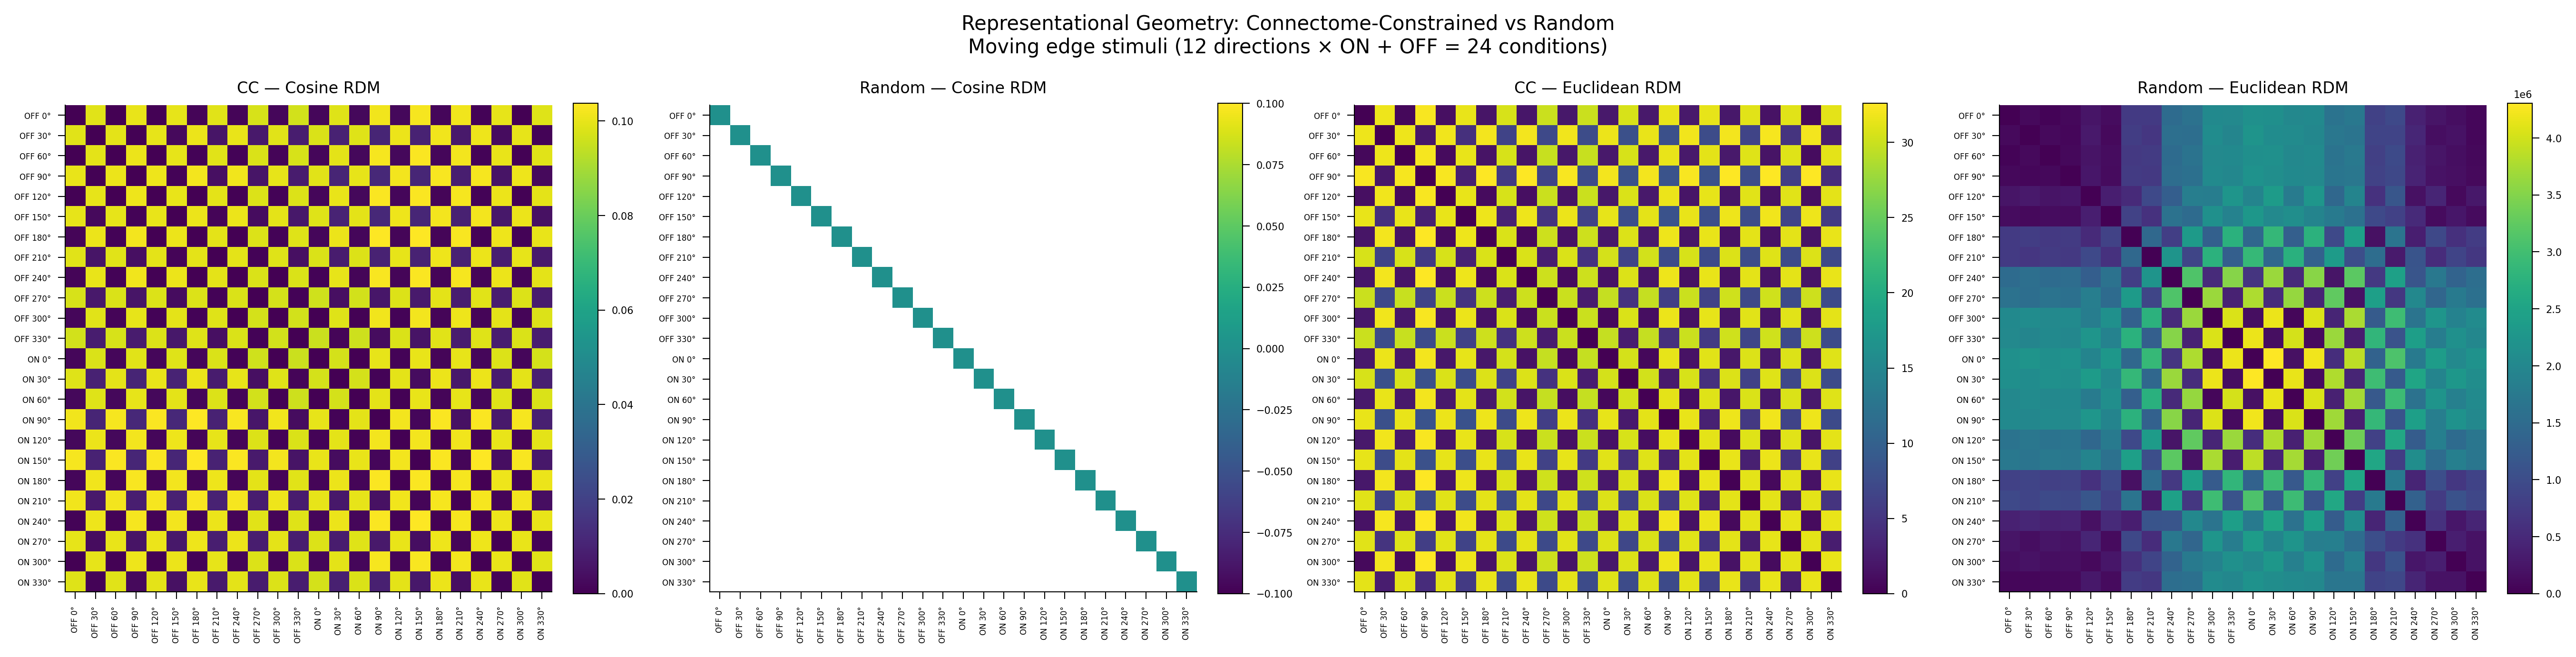


SUMMARY
  N stimuli:          24 (ON + OFF edges, 12 directions each)
  N models:           50
  Population vec dim: 65 (cell types)
  Cosine RDM corr (CC vs random):    Spearman r = nan | Kendall τ = nan
  Euclidean RDM corr (CC vs random): Spearman r = 0.313 | Kendall τ = 0.229
  Within-CC consistency:             r = 0.838


{'cc_rdm_cosine': array([[0.        , 0.09920105, 0.00017287, 0.10034801, 0.00065863,
         0.09991537, 0.00128067, 0.09903332, 0.00145632, 0.0972988 ,
         0.00163253, 0.09683304, 0.0018904 , 0.09860764, 0.00223827,
         0.10157373, 0.00219054, 0.10232886, 0.00171847, 0.10155565,
         0.000857  , 0.09979427, 0.00021624, 0.09852644],
        [0.09920105, 0.        , 0.09946348, 0.00057731, 0.10005087,
         0.00247404, 0.10087565, 0.00579521, 0.10035358, 0.00689483,
         0.0989108 , 0.0081323 , 0.09774899, 0.00998286, 0.09853246,
         0.01085062, 0.10057922, 0.00975791, 0.10159371, 0.00702922,
         0.10109797, 0.00355459, 0.09999734, 0.00104214],
        [0.00017287, 0.09946348, 0.        , 0.10050901, 0.00030221,
         0.09995903, 0.00092173, 0.09921773, 0.0011413 , 0.09778481,
         0.00146173, 0.09761437, 0.00187732, 0.09958566, 0.00223125,
         0.10249225, 0.00209099, 0.10292354, 0.00167746, 0.10195153,
         0.00094629, 0.10017885, 0.0004

In [8]:
results = run_experiment(n_models=50)
results

## Results

### CC Cosine RDM
The connectome-constrained network produces a structured 24×24 dissimilarity matrix with clear polarity-dependent block organization. Within each polarity block (ON-ON and OFF-OFF), the same circular direction gradient observed in Experiment 1 is preserved: adjacent directions are most similar and opposite directions most dissimilar. Across polarity (ON vs OFF pairs), dissimilarities are large and nearly uniform at ~0.099–0.103 — the network represents ON and OFF edges as geometrically distinct populations regardless of direction. This block structure is consistent with the known segregation of the fly visual system into ON (T4) and OFF (T5) pathways.

### Random Cosine RDM
The mean random cosine RDM collapses to NaN across all off-diagonal entries, as in Experiment 1, due to numerical overflow from unstable random models. The cosine metric remains unsuitable for the random baseline at n=50 under the synapse-only shuffle strategy.

### Dynamic Instability
35 of 50 random models (70%) produced exploding activations — comparable to the synapse-only shuffle rate in Experiment 1 (34/50, 68%). The majority of unstable models produced 1,512 non-finite values each, exactly double the 756 observed in Experiment 1, consistent with the doubling of stimulus conditions from 12 to 24. One model (model 18) produced 378 non-finite values — partial instability affecting a subset of stimuli rather than full collapse. 0 of 50 CC models showed any instability. The instability rate is fully consistent across both experiments.

### CC vs Random RDM Correlation
Cosine RDM correlation: **r = NaN** — not computable due to numerical overflow in the mean random cosine RDM, as in Experiment 1.

Euclidean RDM correlation: **Spearman r = 0.313, p < 0.0001 | Kendall τ = 0.229, p < 0.0001** — nominally significant, but not scientifically interpretable. The mean random Euclidean RDM is dominated by extreme magnitudes (~10²–10⁶) from the 35 unstable random models, whose exploding activations create structured variance in the Euclidean distances that incidentally correlates with the CC pattern. This is a numerical artifact of the instability, not a meaningful fidelity signal.

**Interpretive note**: The random baseline instability finding is consistent across both experiments. The meaningful fidelity signal in Experiment 2 is the CC representational structure itself — specifically, the polarity block organization — and the within-ensemble consistency reported below.

### Within-Ensemble Consistency
Mean pairwise RDM correlation across all 50 CC models: **r = 0.838 ± 0.059**. This is notably higher and tighter than the n=50 ON-only result (r = 0.721 ± 0.150), suggesting that the ON+OFF stimulus set produces a more consistent representational geometry across the ensemble — likely because 24 conditions provide a richer constraint on the population code than 12. The result also matches the n=10 ON-only within-ensemble consistency (r = 0.838 ± 0.078), suggesting the full ensemble converges on a stable geometry when stimulus coverage is sufficient.

### Next Steps
- The CC cosine RDM reveals a clear polarity block structure — ON and OFF edges occupy geometrically distinct regions of population space, consistent with T4/T5 pathway segregation; this is itself a fidelity-relevant finding worth reporting in the SfN abstract
- The within-ensemble consistency improvement at n=50 from ON-only (r = 0.721) to ON+OFF (r = 0.838) suggests polarity is a stronger organizer of representational geometry than direction alone — worth investigating further
- Cosine distance remains the appropriate primary metric; the random baseline instability pattern is now confirmed to be stimulus-count-invariant (756 per unstable model per 12 stimuli)

## Download Figure

In [9]:
# Download figure to local machine
from google.colab import files
files.download("moving_edge_on_off_rdms_50models.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>